# 🪣 Notebook 1: Token Bucket

**Token bucket** = a bucket that refills at a steady rate `r` tokens/second,
up to a maximum cap `B`. Each request consumes one token. If the bucket is
empty, the request is rejected (or queued).

### Mental picture 🎨
```
    drip … drip … drip   (refill at r=5 tokens/sec)
        │
        ▼
  ┌───────────────┐
  │ ● ● ● ● ● ●   │   bucket capacity B=10
  └───────────────┘
        │ 1 token per request
        ▼
     [ API ]
```

It allows **bursts up to `B`** while keeping the long-term average ≤ `r`.
Used by AWS, GCP, Stripe, NGINX, etc.


## 🛠️ Setup

```bash
cd 04-patterns/rate-limiting-and-throttling
uv sync
```

Select the `.venv` kernel in VS Code (top-right of the notebook). If it doesn't appear, reload the window: `Cmd+Shift+P` → **Reload Window**.


## ❌ Bad first try — refill only on a timer

A common beginner mistake: refill the bucket in a background timer
(`every 1s, add r tokens`). This is imprecise — the bucket has stale
state between ticks, tokens get "bunched" at tick boundaries, and tests
become flaky. **Don't do this in production.**


In [1]:
import time

class TimerRefillBucket:
    """Bad: relies on an external timer calling refill()."""
    def __init__(self, rate, capacity):
        self.rate = rate
        self.capacity = capacity
        self.tokens = capacity

    def refill(self):
        # Must be called exactly every 1s by someone else…
        self.tokens = min(self.capacity, self.tokens + self.rate)

    def allow(self):
        if self.tokens >= 1:
            self.tokens -= 1
            return True
        return False

# If the "timer" is late, clients get starved. If it's early, they get free tokens.
bad = TimerRefillBucket(rate=5, capacity=10)
print("immediate burst:", [int(bad.allow()) for _ in range(15)])
print("(no refill yet) next 5:", [int(bad.allow()) for _ in range(5)])

immediate burst: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
(no refill yet) next 5: [0, 0, 0, 0, 0]


## ✅ Better: lazy refill based on elapsed time

We compute tokens **on demand**. Each call looks at the clock and adds
`(elapsed * rate)` tokens (capped at `capacity`). This is exact, O(1), and
doesn't need a background thread.


In [2]:
class TokenBucket:
    def __init__(self, rate, capacity):
        self.rate = rate            # tokens added per second
        self.capacity = capacity    # max tokens the bucket can hold
        self.tokens = capacity      # start full
        self.last = time.monotonic()

    def allow(self, n=1):
        now = time.monotonic()
        # Lazy refill: add exactly what should have arrived since last call.
        self.tokens = min(self.capacity, self.tokens + (now - self.last) * self.rate)
        self.last = now
        if self.tokens >= n:
            self.tokens -= n
            return True
        return False

tb = TokenBucket(rate=5, capacity=10)
results = [tb.allow() for _ in range(20)]
print('burst result (1=allow, 0=deny):', [int(r) for r in results])
print(f'allowed {sum(results)} of {len(results)} — bucket emptied after the burst')

time.sleep(1.0)
print('after 1s wait:', [int(tb.allow()) for _ in range(8)])

burst result (1=allow, 0=deny): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
allowed 10 of 20 — bucket emptied after the burst


after 1s wait: [1, 1, 1, 1, 1, 0, 0, 0]


## 📊 Visualize it

Let's feed a **steady 20 req/sec** stream into a `rate=5, capacity=10`
bucket for 3 seconds and plot which requests were allowed vs denied.
You should see the initial burst of ~10 allows (draining the bucket),
then one allow every 0.2s (the refill rate).


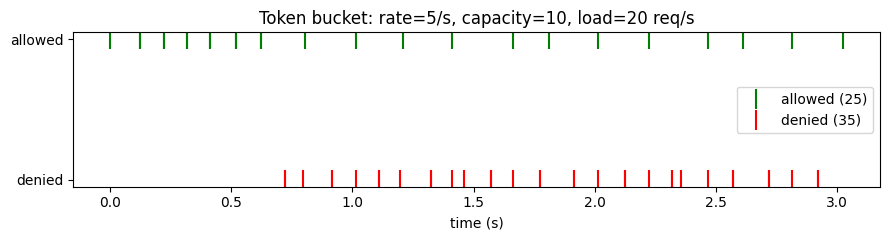

In [3]:
import matplotlib.pyplot as plt

tb = TokenBucket(rate=5, capacity=10)
t0 = time.monotonic()
times, allowed = [], []
duration, req_per_sec = 3.0, 20
interval = 1.0 / req_per_sec
next_t = t0
while time.monotonic() - t0 < duration:
    now = time.monotonic()
    if now < next_t:
        time.sleep(next_t - now)
    ok = tb.allow()
    times.append(time.monotonic() - t0)
    allowed.append(1 if ok else 0)
    next_t += interval

plt.figure(figsize=(9, 2.5))
plt.scatter([t for t, a in zip(times, allowed) if a], [1]*sum(allowed),
            color='green', marker='|', s=200, label=f'allowed ({sum(allowed)})')
plt.scatter([t for t, a in zip(times, allowed) if not a], [0]*(len(allowed)-sum(allowed)),
            color='red', marker='|', s=200, label=f'denied ({len(allowed)-sum(allowed)})')
plt.yticks([0, 1], ['denied', 'allowed'])
plt.xlabel('time (s)')
plt.title('Token bucket: rate=5/s, capacity=10, load=20 req/s')
plt.legend(loc='center right')
plt.tight_layout(); plt.show()

## 🔑 Per-key limiting (one bucket per user / IP)

Real APIs keep **one bucket per client key**. The key is usually:

- an **API key** (paid customer tier),
- a **user id** (logged-in user),
- or the **client IP** (anonymous traffic — but watch out for NAT and IPv6!).


In [4]:
class KeyedTokenBucket:
    def __init__(self, rate, capacity):
        self.rate = rate
        self.capacity = capacity
        self.buckets = {}   # key -> (tokens, last_time)

    def allow(self, key, n=1):
        now = time.monotonic()
        tokens, last = self.buckets.get(key, (self.capacity, now))
        tokens = min(self.capacity, tokens + (now - last) * self.rate)
        if tokens >= n:
            self.buckets[key] = (tokens - n, now)
            return True
        self.buckets[key] = (tokens, now)
        return False

kb = KeyedTokenBucket(rate=2, capacity=4)
alice = sum(kb.allow("alice") for _ in range(10))
bob   = sum(kb.allow("bob")   for _ in range(10))
print(f"alice allowed {alice}/10, bob allowed {bob}/10 — independent buckets")

alice allowed 4/10, bob allowed 4/10 — independent buckets


## 🧠 When to reach for token bucket

- ✅ You want **generous short bursts** but a sensible long-term average.
- ✅ You need **O(1) memory per key** (just 2 numbers: tokens, last_time).
- ❌ You need **perfectly smooth output** — use leaky bucket (next notebook).
- ❌ You need **exact per-window fairness** — use sliding window (nb 3).

### Real-world examples
- **AWS API Gateway** — token bucket with burst + steady rate.
- **Stripe API** — 100 read req/sec, burstable.
- **NGINX `limit_req_zone`** — leaky-bucket variant; token bucket is `burst=`.
